# Fruits-360 expanded CNN experiments

This notebook is an evidence reader and rerun companion. It does **not** invent results: all displayed measurements are loaded from the saved expanded training output. Training is opt-in in the final cell.

## Experimental protocol

The protocol compares ReLU, sigmoid, tanh and Leaky ReLU at learning rates 0.001, 0.01 and 0.1 while holding the split, architecture, seed, batch size and epoch budget fixed. Selection uses validation macro F1; held-out test metrics are reported only from the saved selected run.

In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / 'experiments').exists():
    ROOT = Path.cwd().parent
EVIDENCE = ROOT / 'artifacts/expanded'
SUMMARY_PATH = EVIDENCE / 'summary.json'
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
summary['scope']

{'dataset': 'Fruits-360 2020.05.18.0 / 131-class snapshot',
 'source_commit': 'ffda2d14eada57a0c5537700190b309cfea2e120',
 'source_url': 'https://github.com/Horea94/Fruit-Images-Dataset',
 'classes': ['Apple Braeburn',
  'Apple Crimson Snow',
  'Apple Golden 1',
  'Apple Golden 2',
  'Apple Golden 3',
  'Apple Granny Smith',
  'Apple Pink Lady',
  'Apple Red 1',
  'Apple Red 2',
  'Apple Red 3',
  'Apple Red Delicious',
  'Apple Red Yellow 1',
  'Apple Red Yellow 2',
  'Apricot',
  'Avocado',
  'Avocado ripe',
  'Banana',
  'Banana Lady Finger',
  'Banana Red',
  'Beetroot',
  'Blueberry',
  'Cactus fruit',
  'Cantaloupe 1',
  'Cantaloupe 2',
  'Carambula',
  'Cauliflower',
  'Cherry 1',
  'Cherry 2',
  'Cherry Rainier',
  'Cherry Wax Black',
  'Cherry Wax Red',
  'Cherry Wax Yellow',
  'Chestnut',
  'Clementine',
  'Cocos',
  'Corn',
  'Corn Husk',
  'Cucumber Ripe',
  'Cucumber Ripe 2',
  'Dates',
  'Eggplant',
  'Fig',
  'Ginger Root',
  'Granadilla',
  'Grape Blue',
  'Grape Pink',

## Actual training implementation

The following import exposes the production training module. It is not a notebook-only reimplementation; the opt-in command below calls this exact script so artifacts, split manifest and evidence schema remain aligned.

In [2]:
import importlib.util
trainer_path = ROOT / 'experiments/train_expanded.py'
spec = importlib.util.spec_from_file_location('train_expanded', trainer_path)
train_expanded = importlib.util.module_from_spec(spec) if trainer_path.exists() else None
if train_expanded is not None:
    spec.loader.exec_module(train_expanded)
print(f'Training module: {trainer_path} ({"loaded" if train_expanded is not None else "not present yet"})')

Training module: /home/hermes/workspace/projects/prootypie/experiments/train_expanded.py (loaded)


## Architecture and data path

The training source owns the authoritative model architecture and dataset loading. Reading it here makes the exact code reviewable without duplicating or drifting from the training entry point.

In [3]:
if trainer_path.exists():
    source_text = trainer_path.read_text(encoding='utf-8')
    print(source_text[:12000])
else:
    print('Expected training entry point is not present in this checkout:', trainer_path)

"""Pinned 131-class Fruits-360 experiment. Never overwrites the small pilot.
Run: python experiments/train_expanded.py --run --epochs 8
CPU threads bounded; each configuration checkpointed independently.
"""
from __future__ import annotations
import os
os.environ.setdefault('TF_NUM_INTRAOP_THREADS','2')
os.environ.setdefault('TF_NUM_INTEROP_THREADS','2')
os.environ.setdefault('OMP_NUM_THREADS','2')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','2')
import argparse,csv,hashlib,json,random,time,zipfile
from pathlib import Path
from collections import defaultdict
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,confusion_matrix
ROOT=Path(__file__).resolve().parents[1]
OUT=ROOT/'artifacts/expanded'
CACHE=Path(os.environ.get('FRUITS360_CACHE',str(ROOT.parent.parent/'datasets/fruits360-131')))
COMMIT='ffda2d14eada57a0c5537700190b309cfea2e120'
SEED=20260919
ACTIVATIONS=['relu','sigmoid','tanh','leaky_rel

## Saved validation evidence

These values come directly from `summary.json`; this cell performs no training and no metric recalculation.

In [4]:
rows = []
for e in summary['experiments']:
    m=e['validation_metrics']
    rows.append((e['activation'], e['learning_rate'], m['accuracy'], m['precision_macro'], m['recall_macro'], m['f1_macro'], e['training_seconds']))
rows

[('relu',
  0.001,
  0.010941889693922815,
  8.470317831507064e-05,
  0.007633587786259542,
  0.00016754723303669174,
  103.15967076190282),
 ('relu',
  0.01,
  0.5301641283454088,
  0.6739823384881992,
  0.5164162372747778,
  0.5214180926420888,
  107.57371689996216),
 ('relu',
  0.1,
  0.9846961407659323,
  0.9843989075341997,
  0.9827942993112975,
  0.9809841351778984,
  97.18448634003289),
 ('sigmoid',
  0.001,
  0.010941889693922815,
  8.352587552612836e-05,
  0.007633587786259542,
  0.0001652436730095674,
  104.31767959299032),
 ('sigmoid',
  0.01,
  0.01456454236285672,
  0.00011117971269356275,
  0.007633587786259542,
  0.00021916735318707714,
  103.81269913399592),
 ('sigmoid',
  0.1,
  0.10084282123318054,
  0.032844440785869664,
  0.07903587010410425,
  0.03198261174799555,
  102.53495361399837),
 ('tanh',
  0.001,
  0.04702055300901967,
  0.008395181490582304,
  0.033681128319776626,
  0.01129189000175603,
  102.63100146898068),
 ('tanh',
  0.01,
  0.7535856868253733,
  0.7

## All learning curves

Four combined panels ensure every activation and all three learning rates are visible. The histories are saved evidence, not reconstructed predictions.

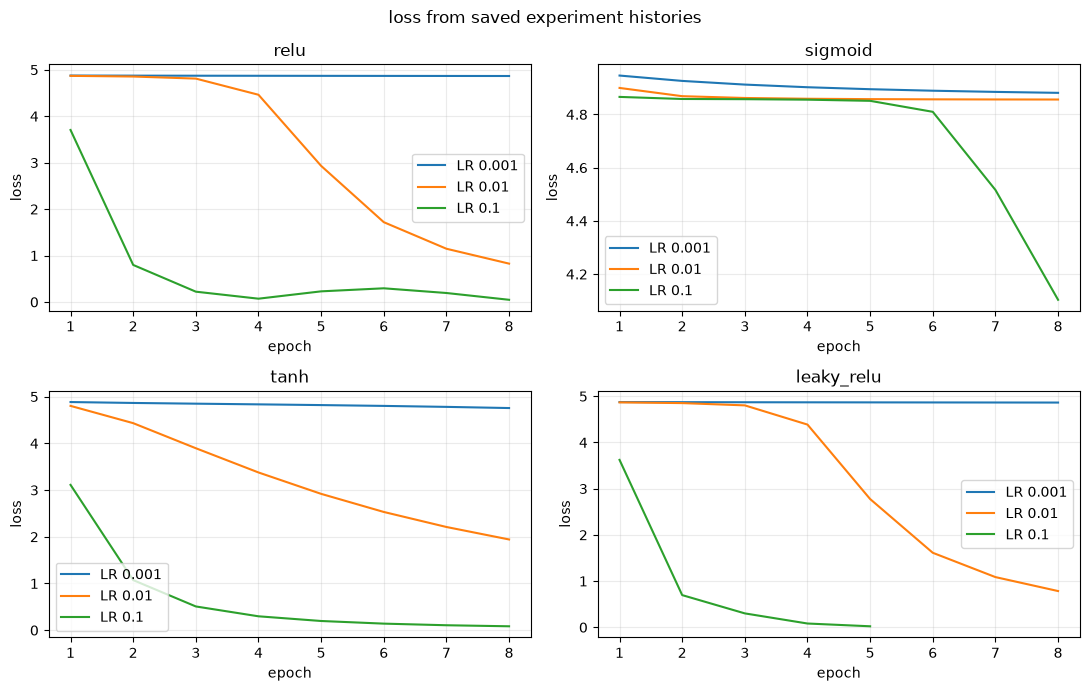

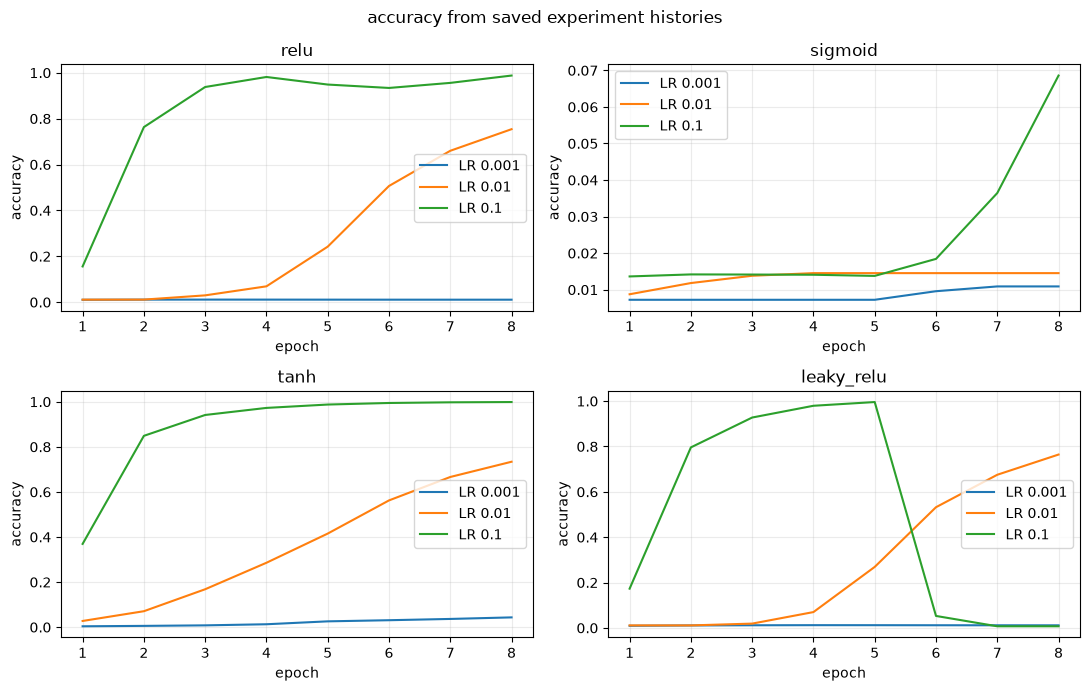

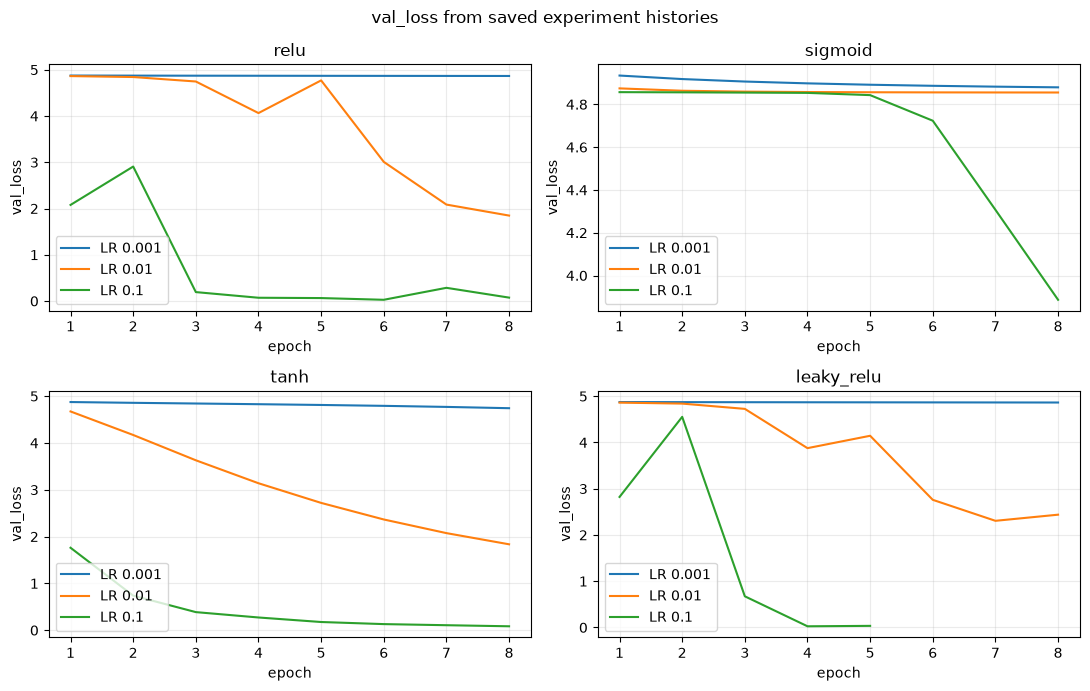

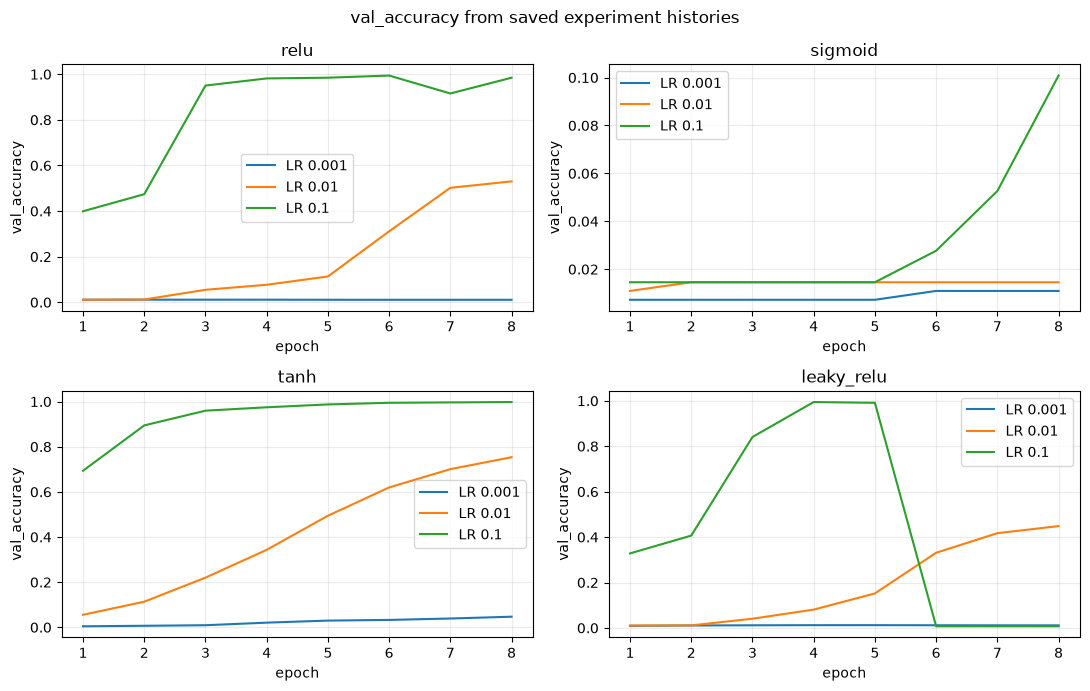

In [5]:
activations = ('relu','sigmoid','tanh','leaky_relu')
for metric in ('loss','accuracy','val_loss','val_accuracy'):
    fig, axes = plt.subplots(2,2,figsize=(11,7))
    for ax, activation in zip(axes.flat, activations):
        for e in sorted([x for x in summary['experiments'] if x['activation']==activation], key=lambda x:x['learning_rate']):
            ax.plot(range(1,len(e['history'][metric])+1), e['history'][metric], label=f"LR {e['learning_rate']:g}")
        ax.set(title=activation, xlabel='epoch', ylabel=metric); ax.legend(); ax.grid(alpha=.25)
    fig.suptitle(metric + ' from saved experiment histories'); fig.tight_layout(); plt.show()

## Test evidence

The matrix and per-class measurements use the saved one-time held-out test output. The class order is exactly `scope.classes`.

{'accuracy': 0.9323430888575458, 'precision_macro': 0.9405931076963597, 'recall_macro': 0.9280795037870013, 'f1_macro': 0.9274328868436194}


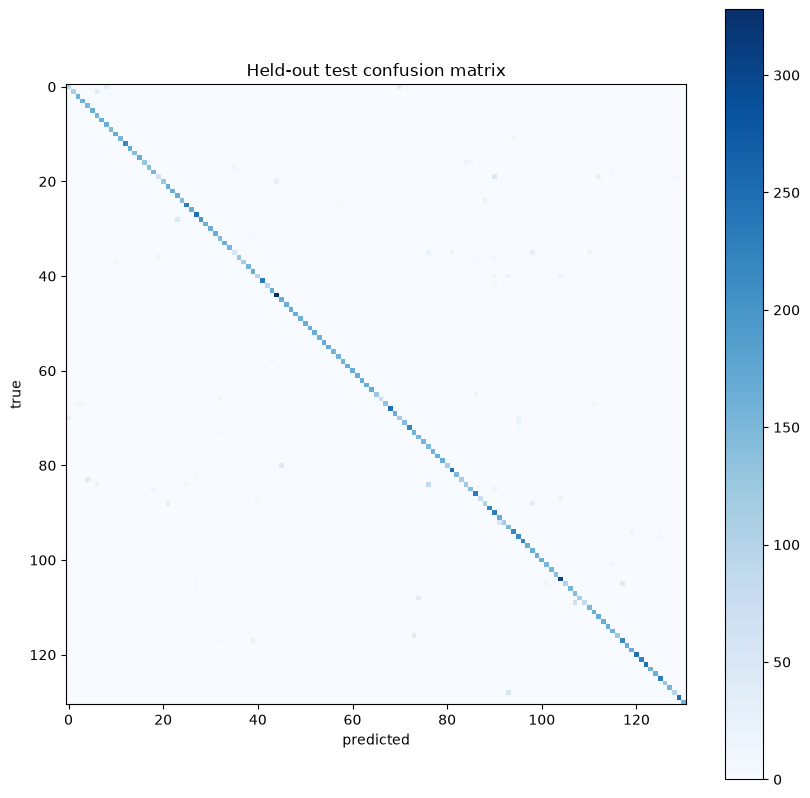

[{'class': 'Apple Braeburn',
  'precision': 0.7637795275590551,
  'recall': 0.5914634146341463,
  'f1': 0.6666666666666666,
  'support': 164},
 {'class': 'Apple Crimson Snow',
  'precision': 1.0,
  'recall': 0.7364864864864865,
  'f1': 0.8482490272373541,
  'support': 148},
 {'class': 'Apple Golden 1',
  'precision': 0.9302325581395349,
  'recall': 1.0,
  'f1': 0.963855421686747,
  'support': 160},
 {'class': 'Apple Golden 2',
  'precision': 0.9523809523809523,
  'recall': 0.975609756097561,
  'f1': 0.963855421686747,
  'support': 164},
 {'class': 'Apple Golden 3',
  'precision': 0.7676767676767676,
  'recall': 0.9440993788819876,
  'f1': 0.8467966573816156,
  'support': 161},
 {'class': 'Apple Granny Smith',
  'precision': 0.9111111111111111,
  'recall': 1.0,
  'f1': 0.9534883720930233,
  'support': 164},
 {'class': 'Apple Pink Lady',
  'precision': 0.7307692307692307,
  'recall': 1.0,
  'f1': 0.8444444444444444,
  'support': 152},
 {'class': 'Apple Red 1',
  'precision': 0.9647058823

In [6]:
print(summary['test_metrics'])
matrix = np.asarray(summary['test_confusion_matrix'])
fig, ax = plt.subplots(figsize=(10,10)); im=ax.imshow(matrix,cmap='Blues'); fig.colorbar(im,ax=ax)
ax.set(xlabel='predicted', ylabel='true', title='Held-out test confusion matrix')
plt.show()
summary['per_class'][:10]

## Interpretation and numerical stability

Tanh at learning rate 0.1 was selected by validation macro F1. Its official-Test accuracy is 93.23%, with macro F1 92.74%. Leaky ReLU at 0.1 developed non-finite loss from epoch 6; its final metrics are unavailable and it is excluded from model selection. This is an observed optimization failure, not a zero score. Lower learning rates generally underfit within eight epochs. These measurements apply to the pinned 131-class snapshot, not external photographs.

In [7]:
# Verify results independently from saved labels and predictions.
import subprocess
subprocess.run([sys.executable,str(ROOT/'scripts/verify_expanded_results.py')],cwd=ROOT,check=True)

{
  "verified": true,
  "configurations": 12,
  "classes": 131,
  "split_counts": {
    "train": 54163,
    "validation": 13526,
    "test": 22688
  },
  "test_metrics_recomputed": {
    "accuracy": 0.9323430888575458,
    "precision_macro": 0.9405931076963597,
    "recall_macro": 0.9280795037870013,
    "f1_macro": 0.9274328868436194
  },
  "best_config": {
    "activation": "tanh",
    "learning_rate": 0.1,
    "selection_metric": "validation macro F1; accuracy tie-break; saved train-only checkpoint, no refit"
  }
}


CompletedProcess(args=['/home/hermes/workspace/projects/prootypie/.venv/bin/python', '/home/hermes/workspace/projects/prootypie/scripts/verify_expanded_results.py'], returncode=0)

## Opt-in rerun

Uncomment the next cell only to rerun the expanded training program. It may take substantial time and overwrites saved evidence. Rebuild the report afterward.

In [8]:
# import subprocess
# subprocess.run([sys.executable, str(trainer_path), '--run'], cwd=ROOT, check=True)
# subprocess.run([sys.executable, str(ROOT/'scripts/build_expanded_submission.py')], cwd=ROOT, check=True)